In [1]:
#!/usr/bin/env python
# coding: utf-8

# =============================================================================
# 导入库，设置绘图参数，配置路径
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 创建输出文件夹
Path('figures/independent_test').mkdir(parents=True, exist_ok=True)

# 绘图参数
sns.set_context("paper")
sns.set_palette('muted')

ss = 8
sss = 8
ssss = 6

matplotlib.rcParams['figure.figsize'] = (3.2, 2.8)
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.style'] = 'normal'
matplotlib.rcParams['font.weight'] = 'bold'
matplotlib.rcParams["axes.labelweight"] = "bold"
matplotlib.rcParams['axes.titlesize'] = sss
matplotlib.rcParams['legend.fontsize'] = ss
matplotlib.rcParams['axes.labelsize'] = ss
matplotlib.rcParams['xtick.labelsize'] = ss
matplotlib.rcParams['ytick.labelsize'] = ss
matplotlib.rcParams['axes.linewidth'] = 0.6
matplotlib.rcParams['lines.linewidth'] = 1.0
matplotlib.rcParams['axes.grid'] = False

COLOR_MAP = {
    'edge': 'tab:orange', 'interior': 'tab:blue',
    'cv': 'steelblue', 'independent': 'coral'
}
ref_line_size = 0.8
scatter_s = 20

# 路径配置
MODEL_DIR   = 'models/ridge'
MODEL_FILE  = f'{MODEL_DIR}/ridge_final_model.pkl'
EDGE_THRESHOLD   = 0.1
ATOM_TYPE_COLS   = ['T_O', 'T_C', 'T_Ti1', 'T_Ti2']
ATOM_TYPE_LABELS = ['O', 'C', 'Ti_inner', 'Ti_outer']


# =============================================================================
# 加载独立测试集，加载模型，预处理，预测，计算评分
# =============================================================================

# 读取独立测试集（单个合并文件）
df_5x6 = pd.read_excel('data/independent_test_set.xlsx')
print(f"独立测试集: {df_5x6['structure_id'].nunique()} 个结构, {len(df_5x6)} 个原子")

# 加载模型
with open(MODEL_FILE, 'rb') as f:
    model_package = pickle.load(f)

ridge_model  = model_package['model']
scaler       = model_package['scaler']
feature_cols = model_package['feature_cols']
target_col   = model_package['target_col']
best_params  = model_package['best_params']

# 特征提取与标准化（只transform，不fit）
X_5x6  = df_5x6[feature_cols].values
y_true = df_5x6[target_col].values
X_5x6_scaled = scaler.transform(X_5x6)

D_E        = df_5x6['D_E'].values
atom_types = df_5x6[ATOM_TYPE_COLS].values

# 预测
y_pred = ridge_model.predict(X_5x6_scaled)

# 评估函数
def calculate_metrics(y_true, y_pred):
    return {
        'mae':       float(mean_absolute_error(y_true, y_pred)),
        'rmse':      float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'r2':        float(r2_score(y_true, y_pred)),
        'n_samples': int(len(y_true))
    }

def classify_and_evaluate(y_true, y_pred, D_E, atom_types):
    results = {}
    results['overall'] = calculate_metrics(y_true, y_pred)

    edge_mask     = D_E < EDGE_THRESHOLD
    interior_mask = ~edge_mask
    results['edge']     = calculate_metrics(y_true[edge_mask],     y_pred[edge_mask])     if edge_mask.sum()     > 0 else {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan, 'n_samples': 0}
    results['interior'] = calculate_metrics(y_true[interior_mask], y_pred[interior_mask]) if interior_mask.sum() > 0 else {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan, 'n_samples': 0}

    results['by_atom_type'] = {}
    for idx, label in enumerate(ATOM_TYPE_LABELS):
        mask = atom_types[:, idx] == 1
        results['by_atom_type'][label] = calculate_metrics(y_true[mask], y_pred[mask]) if mask.sum() > 0 \
            else {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan, 'n_samples': 0}

    return results

ind_results = classify_and_evaluate(y_true, y_pred, D_E, atom_types)

# 加载CV结果用于对比
with open(f'{MODEL_DIR}/ridge_results.json', 'r') as f:
    cv_results = json.load(f)
cv_test = cv_results['cv_results']['test']

# 计算变化率
def pct_change(cv_val, ind_val):
    return (ind_val - cv_val) / cv_val * 100

overall_change  = pct_change(cv_test['overall']['mae_mean'],  ind_results['overall']['mae'])
edge_change     = pct_change(cv_test['edge']['mae_mean'],     ind_results['edge']['mae'])
interior_change = pct_change(cv_test['interior']['mae_mean'], ind_results['interior']['mae'])
cv_ratio  = cv_test['edge']['mae_mean'] / cv_test['interior']['mae_mean']
ind_ratio = ind_results['edge']['mae']  / ind_results['interior']['mae']

# 打印性能摘要
print(f"\n独立测试集性能:")
for cat in ['overall', 'edge', 'interior']:
    r = ind_results[cat]
    print(f"  {cat:10s} - MAE: {r['mae']:.5f}  RMSE: {r['rmse']:.5f}  R²: {r['r2']:.6f}  N: {r['n_samples']}")
print(f"\nMAE变化率 (vs CV Test): 整体 {overall_change:+.2f}%  "
      f"边缘 {edge_change:+.2f}%  内部 {interior_change:+.2f}%")
print(f"边缘/内部比值: CV={cv_ratio:.2f}×  Independent={ind_ratio:.2f}×")

# 保存预测结果CSV
df_predictions = pd.DataFrame({
    'atom_index':   range(len(df_5x6)),
    'structure_id': df_5x6['structure_id'].values,
    'D_E':          D_E,
    'T_O':          df_5x6['T_O'].values.astype(int),
    'T_C':          df_5x6['T_C'].values.astype(int),
    'T_Ti1':        df_5x6['T_Ti1'].values.astype(int),
    'T_Ti2':        df_5x6['T_Ti2'].values.astype(int),
    'y_true':       y_true,
    'y_pred':       y_pred,
    'error':        y_pred - y_true,
    'abs_error':    np.abs(y_pred - y_true)
})
df_predictions.to_csv(f'{MODEL_DIR}/independent_test_predictions.csv', index=False)

# 保存评分CSV
scores_rows = []
for cat in ['overall', 'edge', 'interior']:
    r = ind_results[cat]
    scores_rows.append({'category': cat, 'subcategory': 'all',
                        'mae': r['mae'], 'rmse': r['rmse'],
                        'r2': r['r2'],   'n_samples': r['n_samples']})
for label in ATOM_TYPE_LABELS:
    r = ind_results['by_atom_type'][label]
    scores_rows.append({'category': 'atom_type', 'subcategory': label,
                        'mae': r['mae'], 'rmse': r['rmse'],
                        'r2': r['r2'],   'n_samples': r['n_samples']})
pd.DataFrame(scores_rows).to_csv(f'{MODEL_DIR}/independent_test_scores.csv', index=False)

# 保存结果JSON
full_results = {
    'model_name': 'Ridge',
    'n_structures': df_5x6['structure_id'].nunique(),
    'n_atoms': len(df_5x6),
    'edge_threshold': EDGE_THRESHOLD,
    'overall':  ind_results['overall'],
    'edge':     ind_results['edge'],
    'interior': ind_results['interior'],
    'by_atom_type': ind_results['by_atom_type'],
    'cv_comparison': {
        'cv_test_mae':       cv_test['overall']['mae_mean'],
        'independent_mae':   ind_results['overall']['mae'],
        'mae_change_pct':    overall_change,
        'edge_ratio_cv':     cv_ratio,
        'edge_ratio_ind':    ind_ratio
    },
    'model_info': {'best_params': best_params, 'feature_count': len(feature_cols)}
}
with open(f'{MODEL_DIR}/independent_test_results.json', 'w') as f:
    json.dump(full_results, f, indent=4)

print("\n已保存: independent_test_predictions.csv, "
      "independent_test_scores.csv, independent_test_results.json")




独立测试集: 19 个结构, 8189 个原子

独立测试集性能:
  overall    - MAE: 0.00881  RMSE: 0.01875  R²: 0.999466  N: 8189
  edge       - MAE: 0.05466  RMSE: 0.07014  R²: 0.989948  N: 477
  interior   - MAE: 0.00597  RMSE: 0.00830  R²: 0.999897  N: 7712

MAE变化率 (vs CV Test): 整体 -25.10%  边缘 +6.39%  内部 -15.43%
边缘/内部比值: CV=7.27×  Independent=9.15×

已保存: independent_test_predictions.csv, independent_test_scores.csv, independent_test_results.json


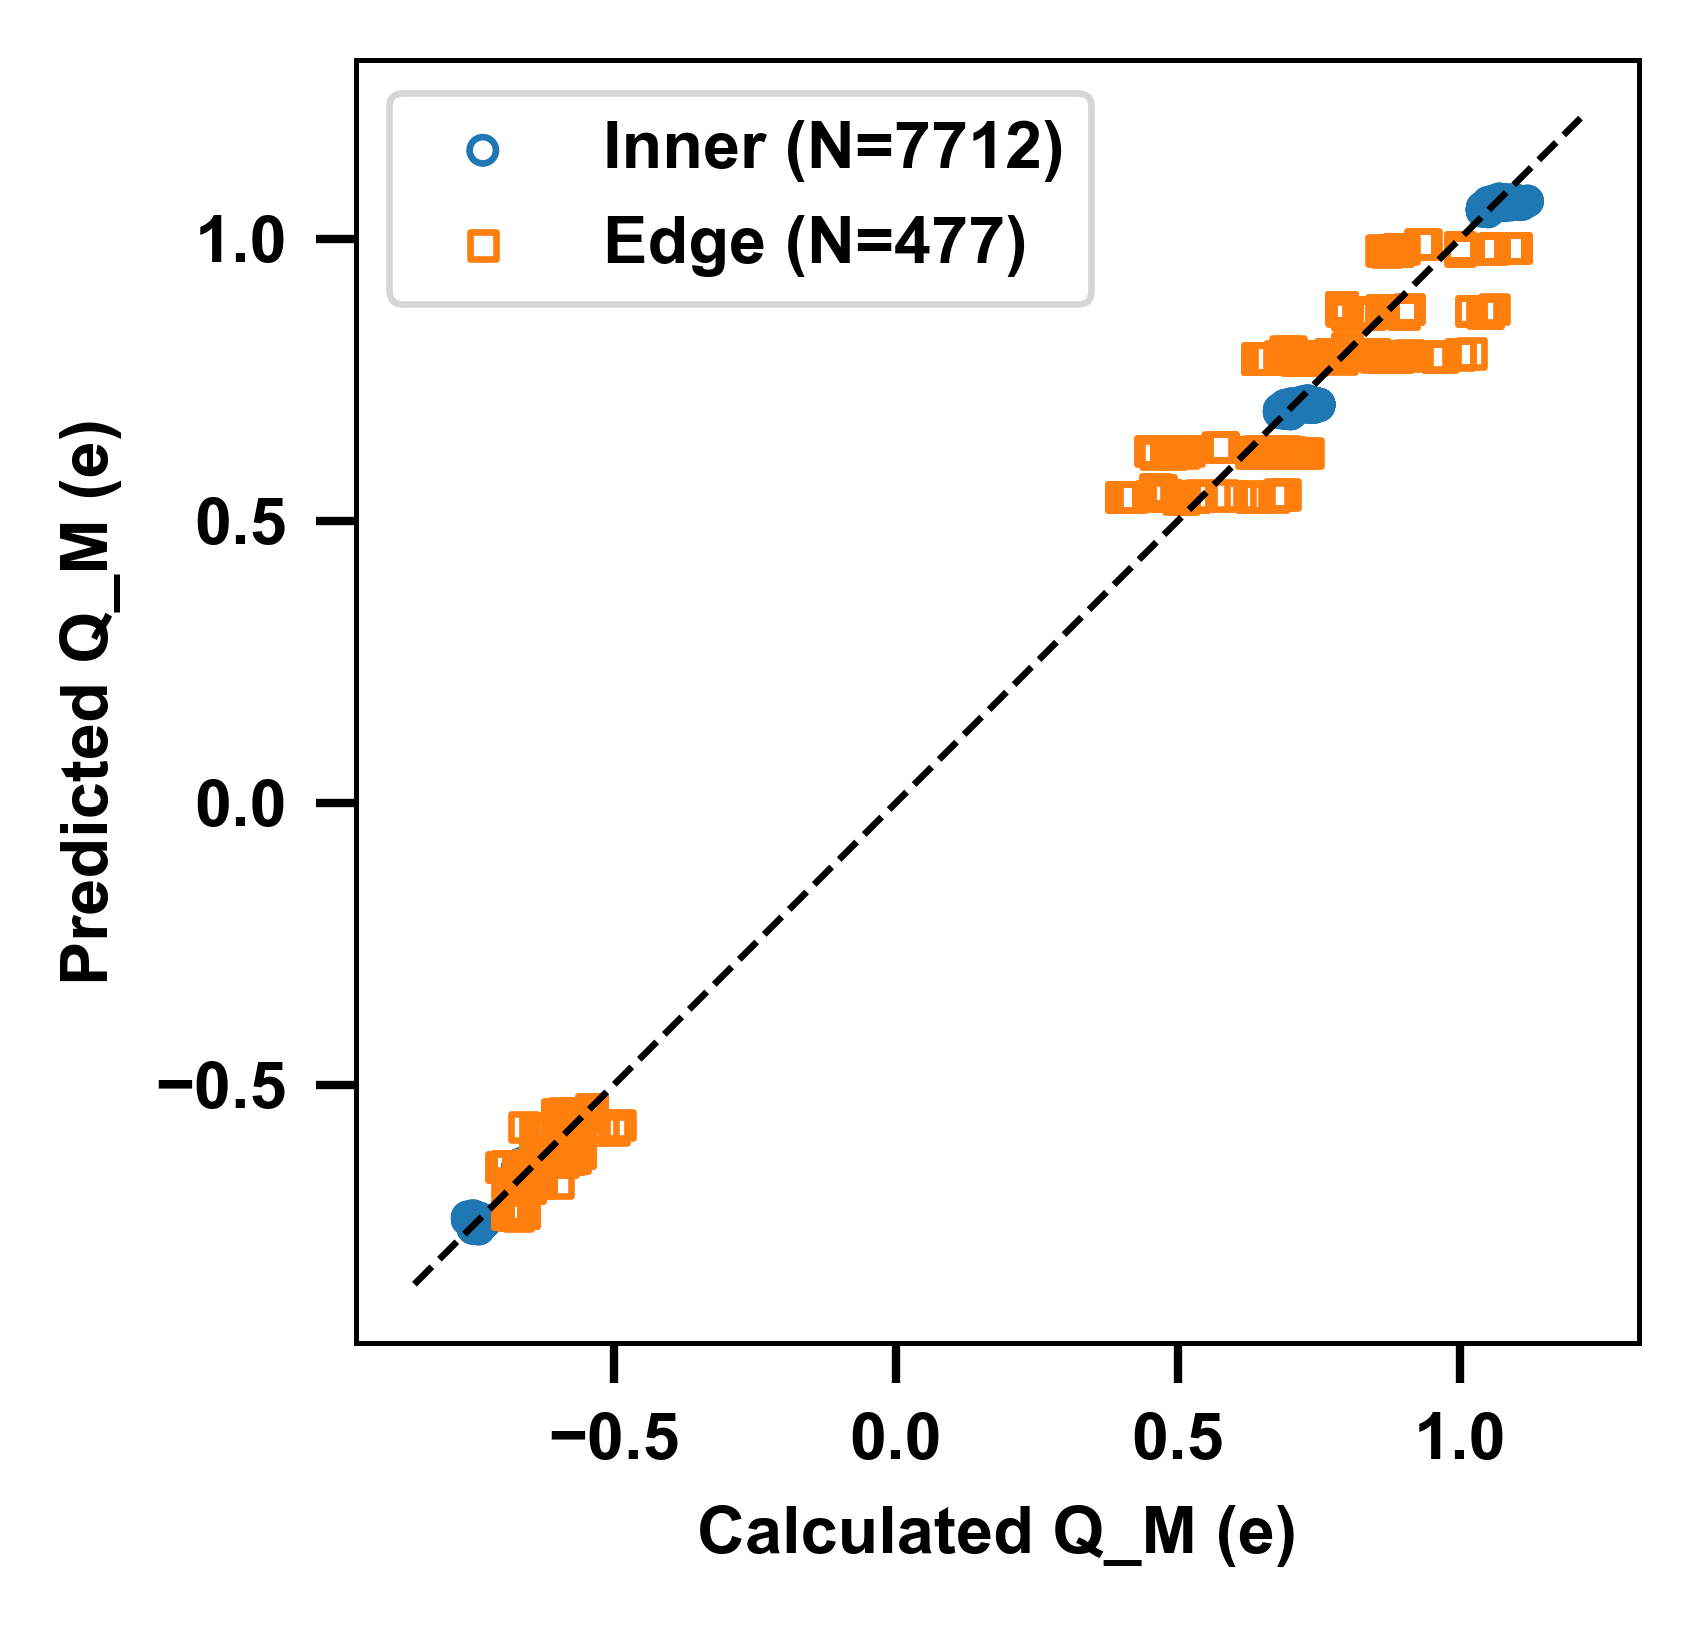

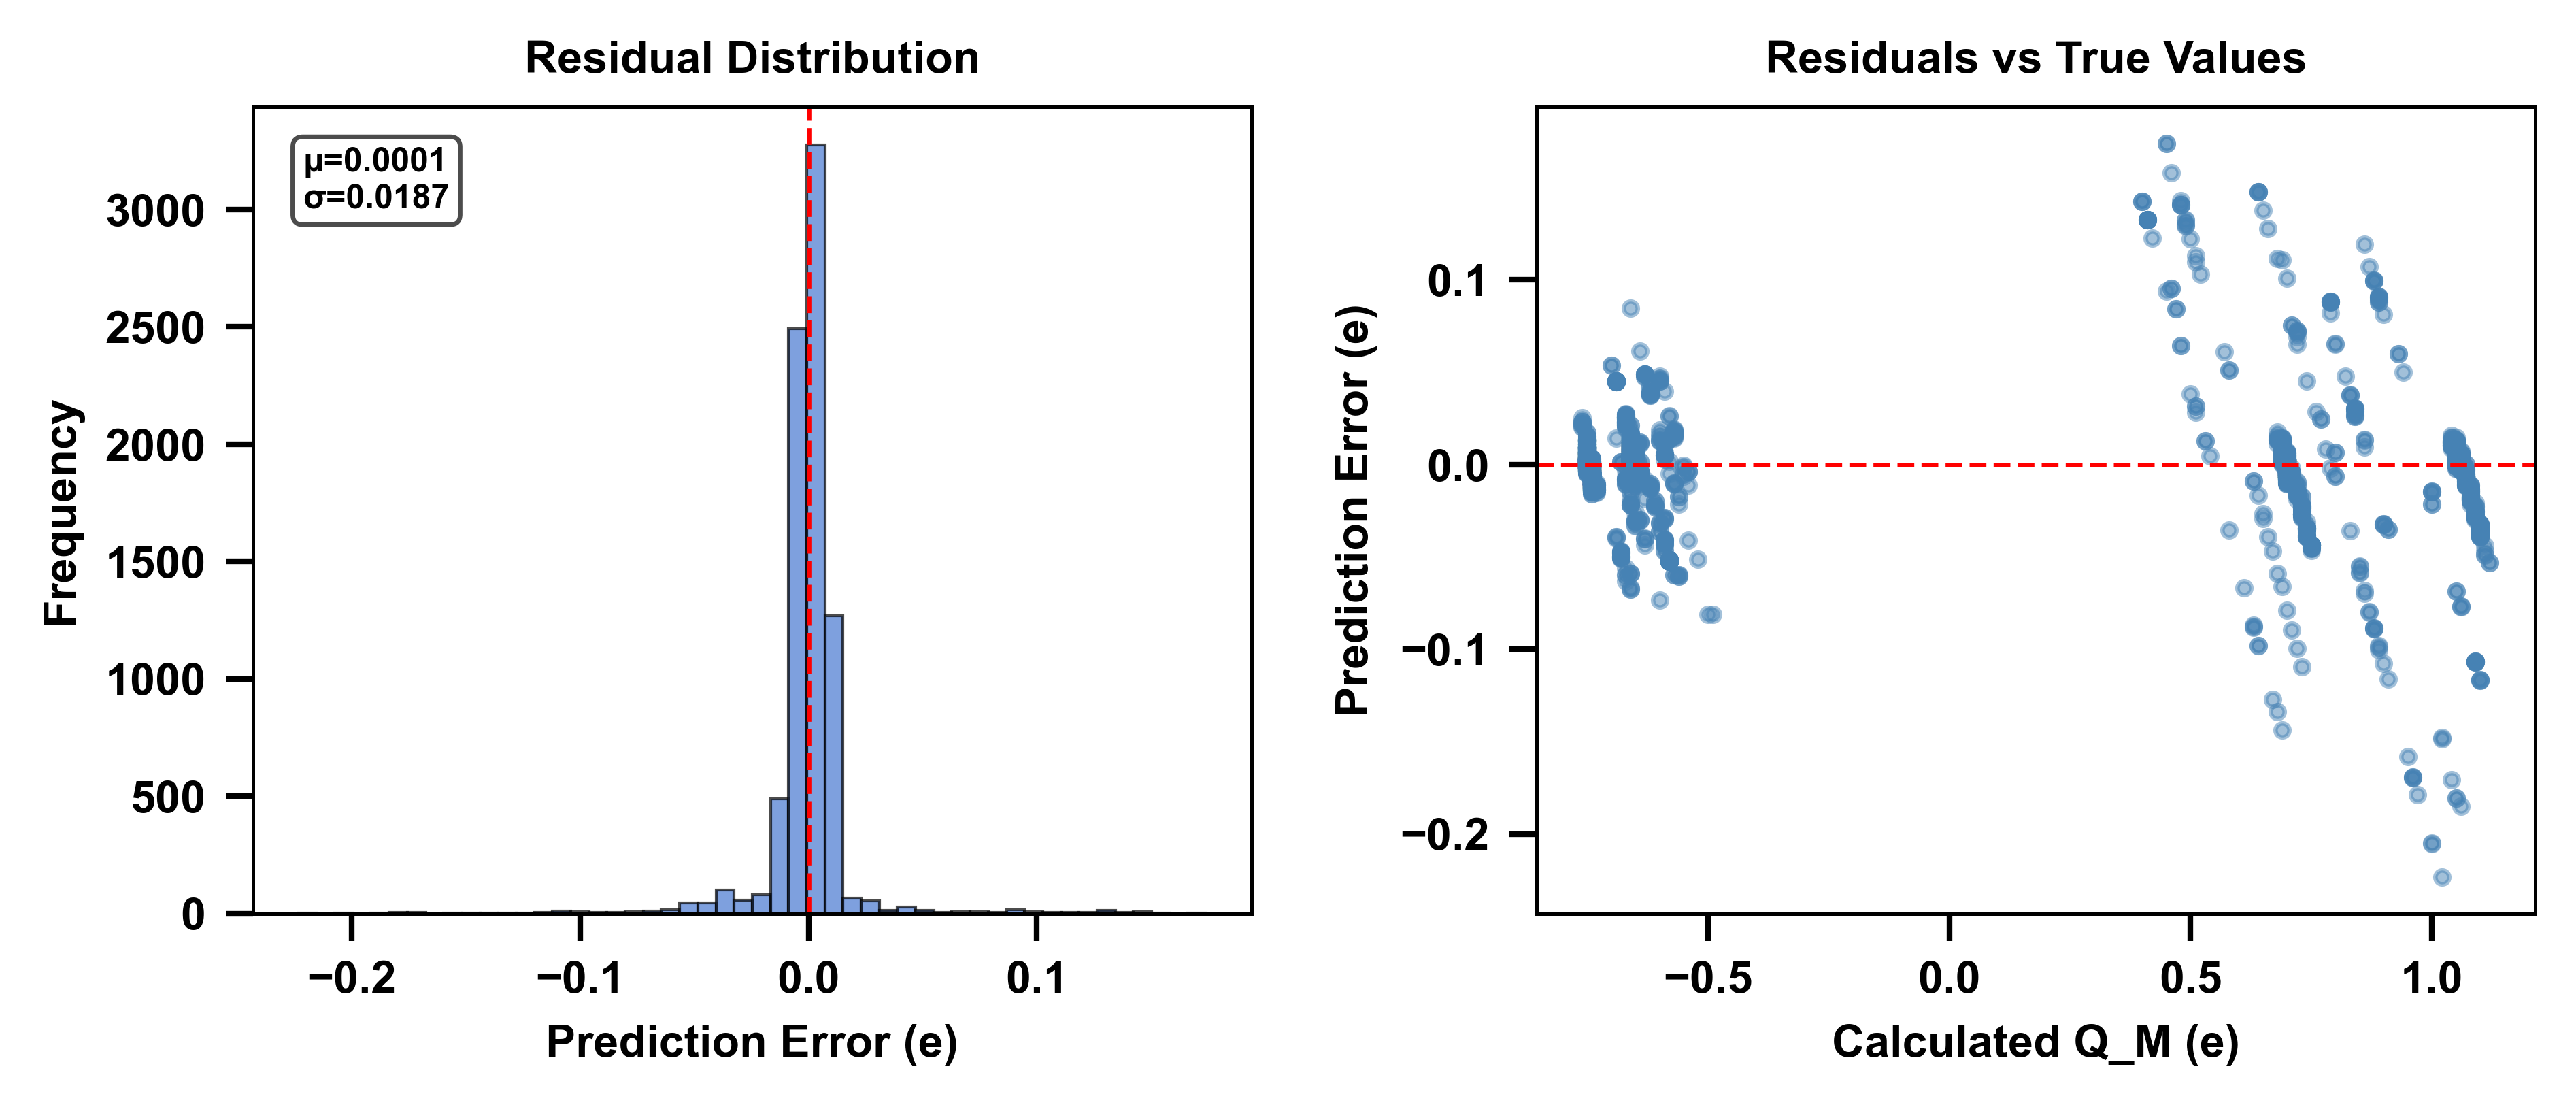

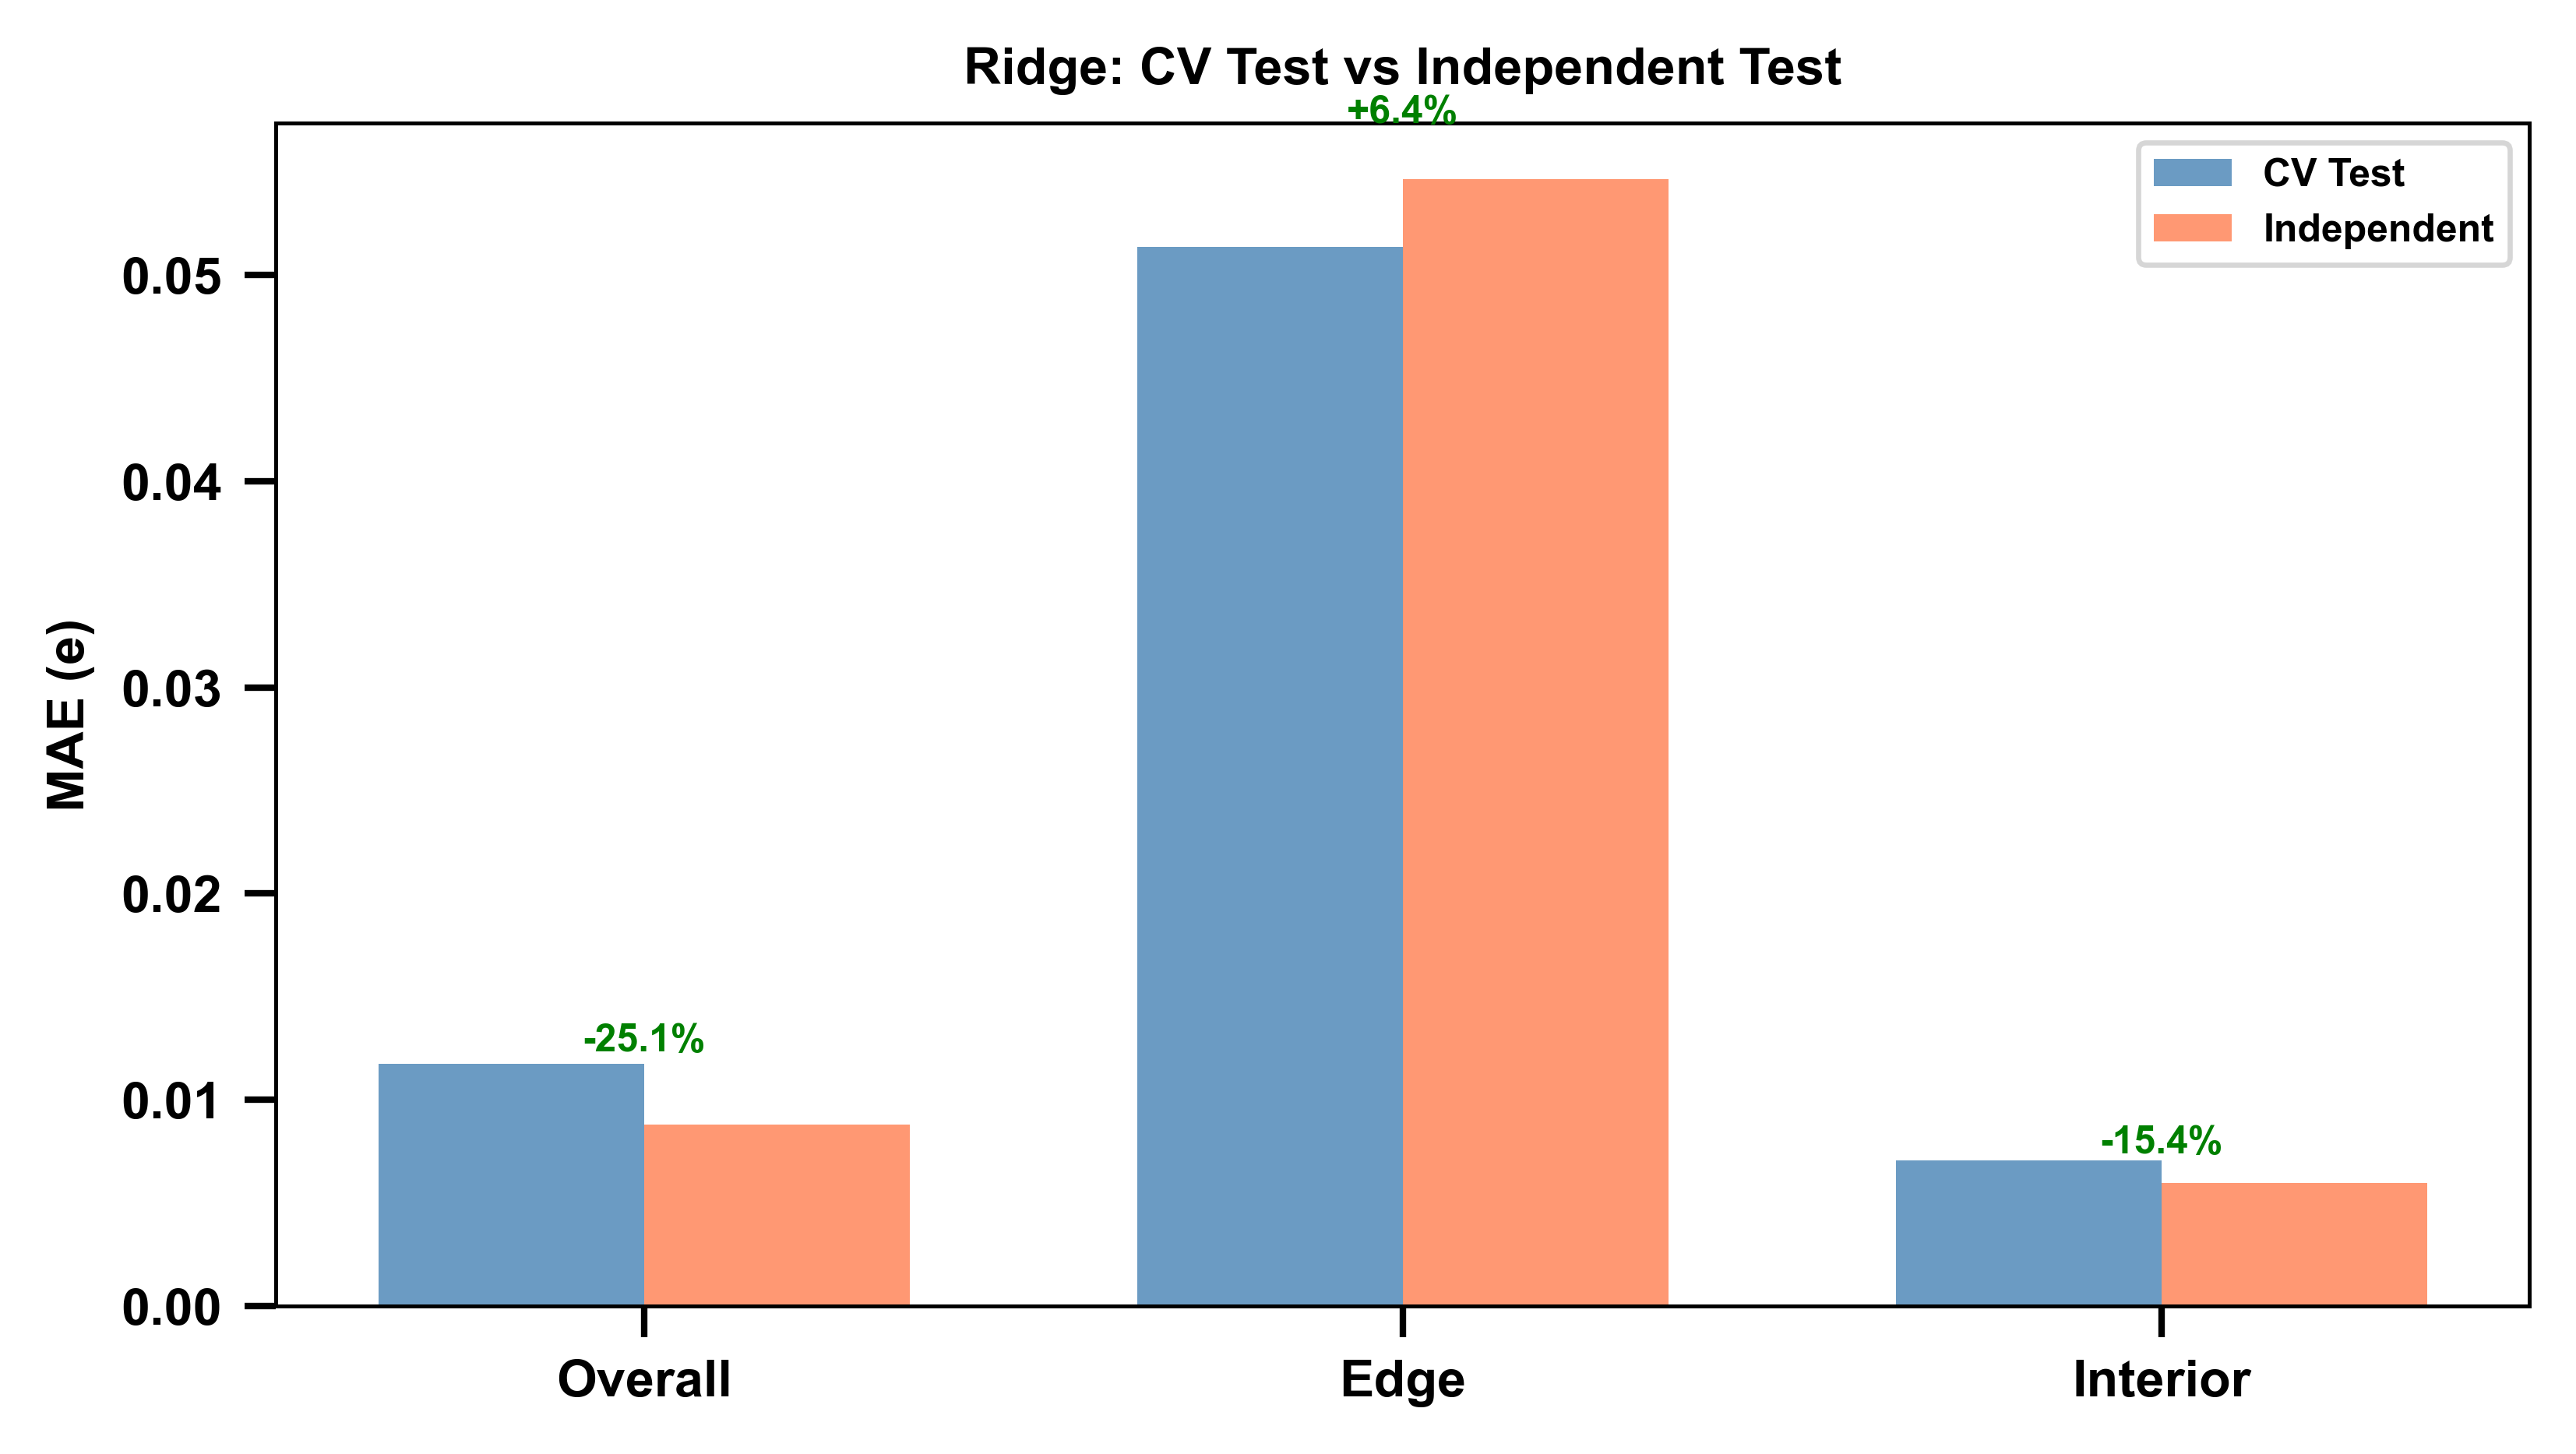

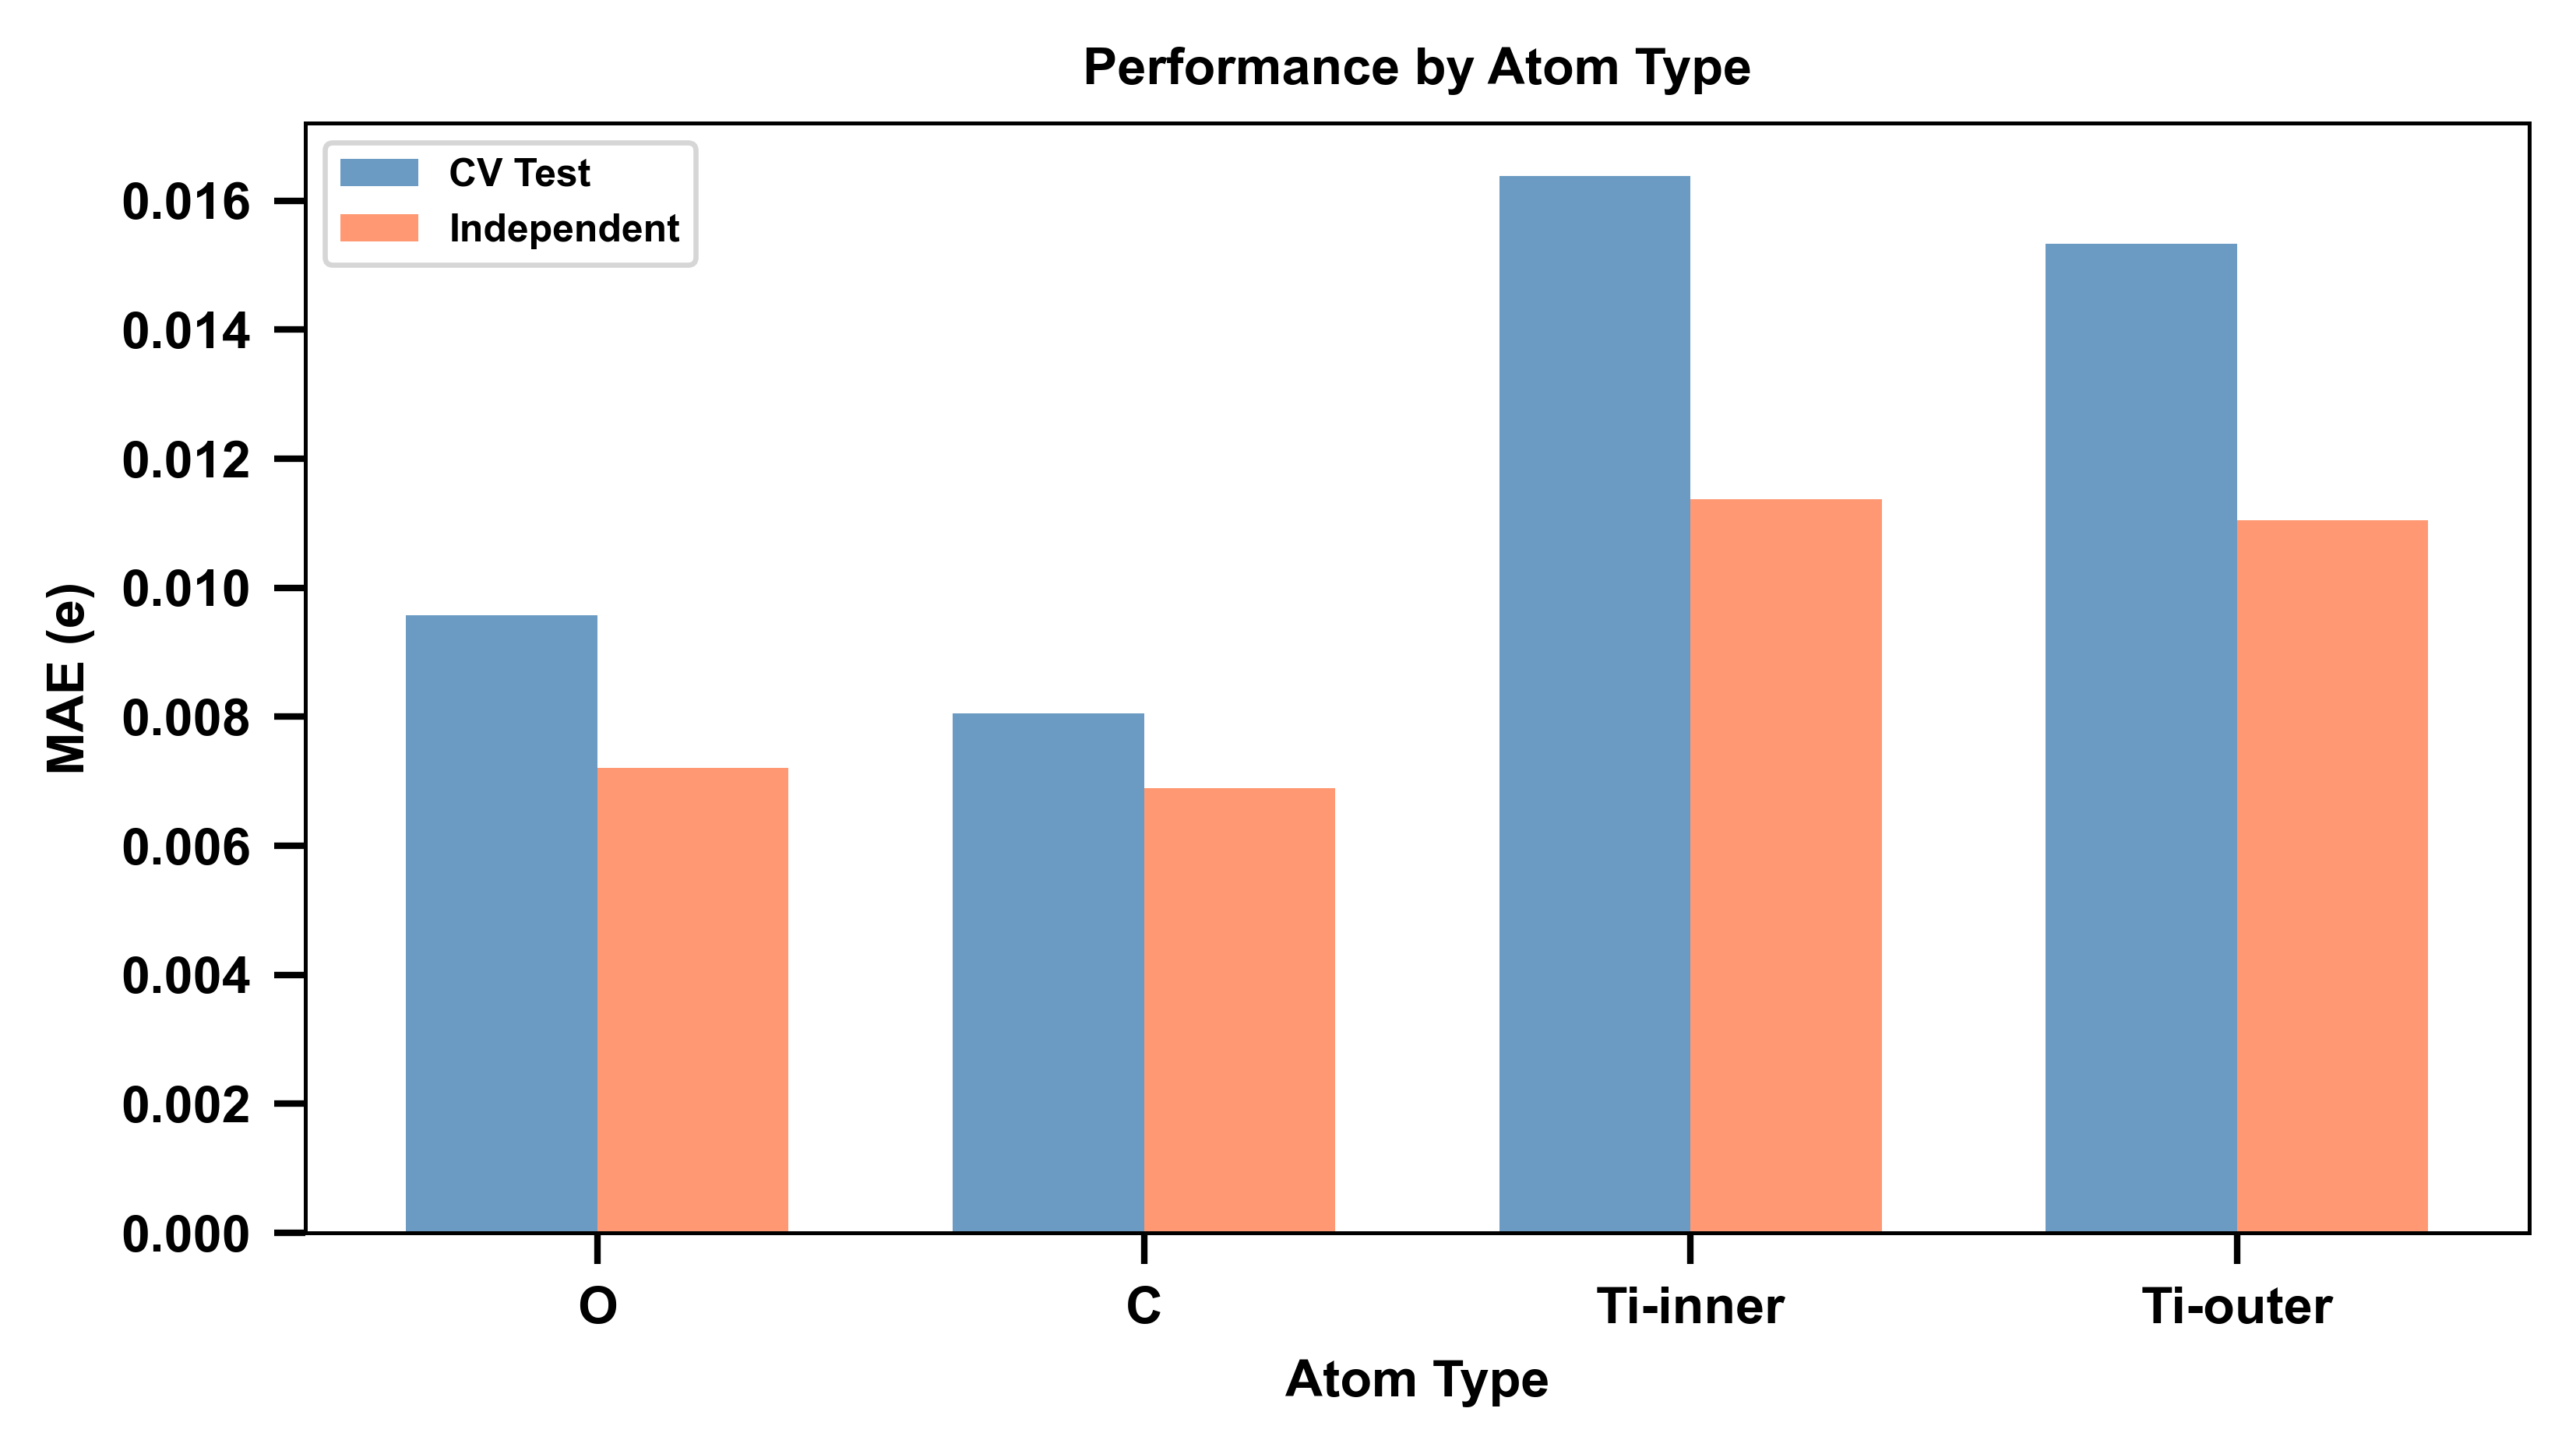

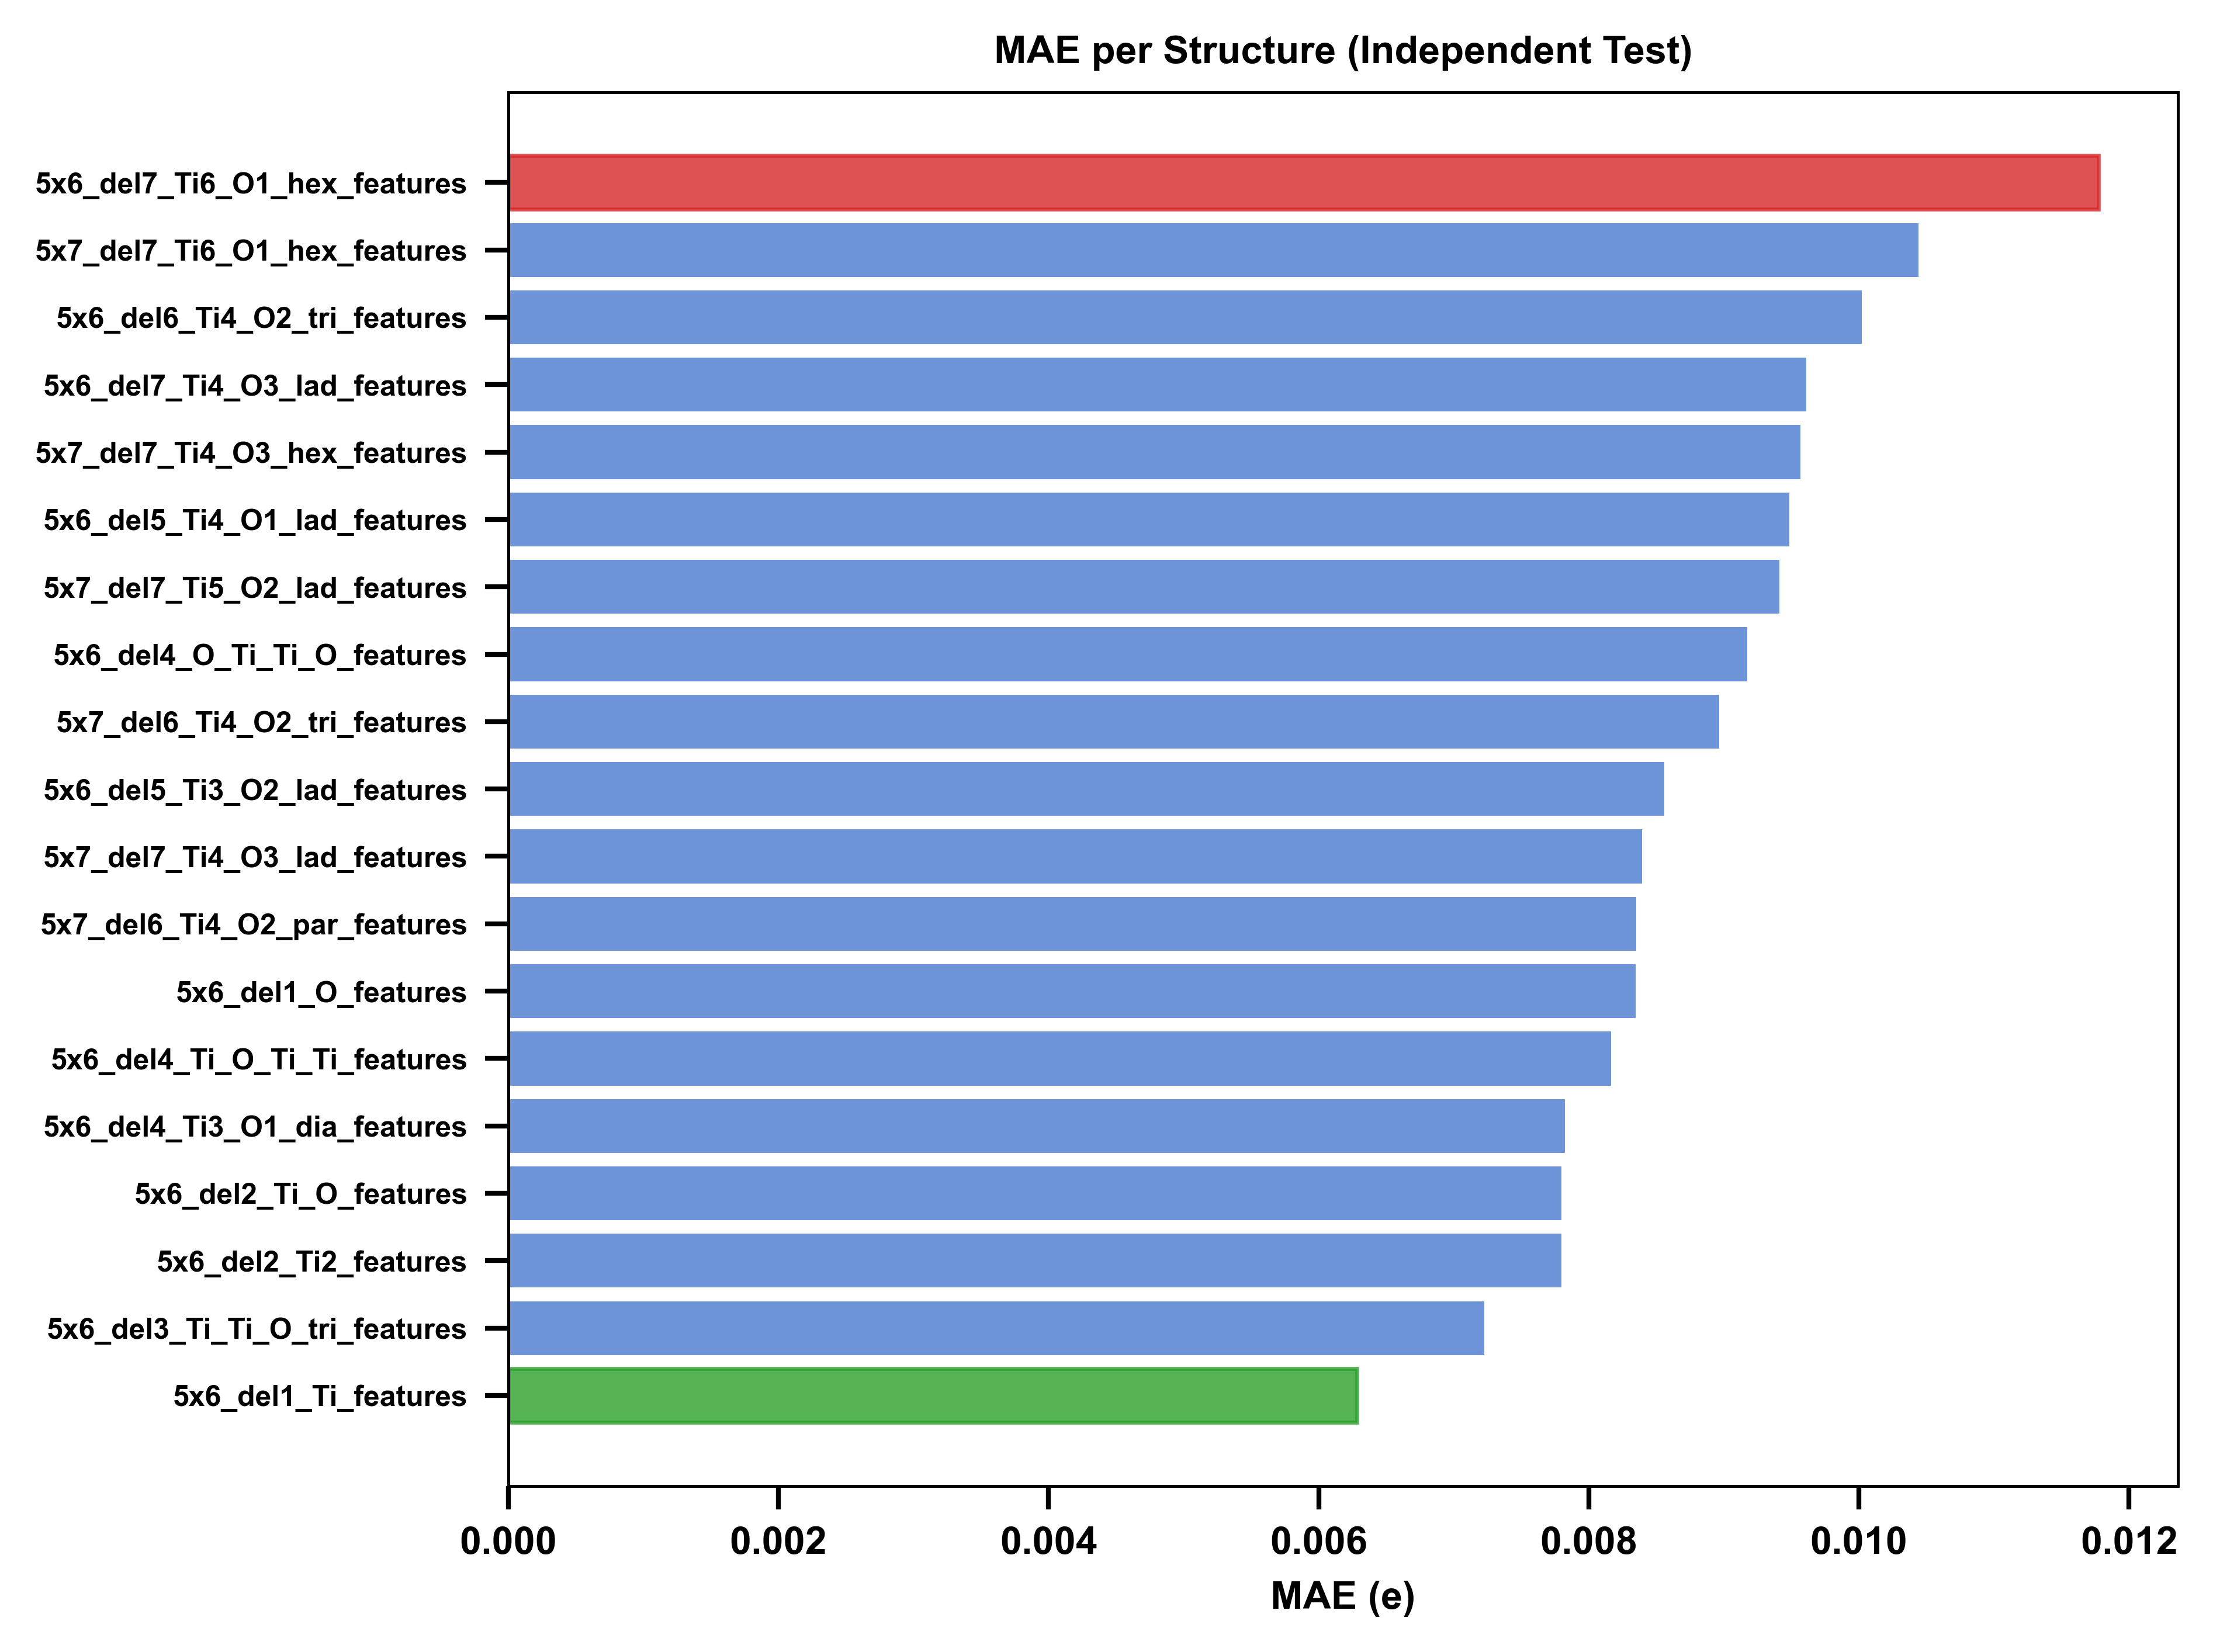

In [2]:
# =============================================================================
# 可视化
# =============================================================================

# 预测vs实际散点图（区分边缘/内部）
edge_mask     = D_E < EDGE_THRESHOLD
interior_mask = ~edge_mask

fig, ax = plt.subplots(figsize=(3.2, 2.8))

ax.scatter(y_true[interior_mask], y_pred[interior_mask],
           s=10, marker='o', facecolors='none',
           edgecolors=COLOR_MAP['interior'], linewidths=0.8,
           label=f'Inner (N={interior_mask.sum()})')
ax.scatter(y_true[edge_mask], y_pred[edge_mask],
           s=10, marker='s', facecolors='none',
           edgecolors=COLOR_MAP['edge'], linewidths=0.8,
           label=f'Edge (N={edge_mask.sum()})')

all_vals = np.concatenate([y_true, y_pred])
vmin, vmax = all_vals.min(), all_vals.max()
margin = (vmax - vmin) * 0.05
ax.plot([vmin-margin, vmax+margin], [vmin-margin, vmax+margin],
        'k--', linewidth=ref_line_size)

ax.set_xlabel('Calculated Q_M (e)')
ax.set_ylabel('Predicted Q_M (e)')
ax.legend(frameon=True, loc='upper left')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('figures/independent_test/ridge_01_pred_vs_true.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/independent_test/ridge_01_pred_vs_true.pdf', dpi=600, bbox_inches='tight')
plt.show()

# 残差分析
errors = y_pred - y_true

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8))

axes[0].hist(errors, bins=50, edgecolor='black', linewidth=0.5, alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=ref_line_size)
axes[0].text(0.05, 0.95, f'μ={np.mean(errors):.4f}\nσ={np.std(errors):.4f}',
             transform=axes[0].transAxes, fontsize=ssss, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[0].set_xlabel('Prediction Error (e)', fontsize=ss, weight='bold')
axes[0].set_ylabel('Frequency', fontsize=ss, weight='bold')
axes[0].set_title('Residual Distribution', fontsize=sss, weight='bold')

axes[1].scatter(y_true, errors, s=scatter_s*0.3, alpha=0.5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=ref_line_size)
axes[1].set_xlabel('Calculated Q_M (e)', fontsize=ss, weight='bold')
axes[1].set_ylabel('Prediction Error (e)', fontsize=ss, weight='bold')
axes[1].set_title('Residuals vs True Values', fontsize=sss, weight='bold')

plt.tight_layout()
plt.savefig('figures/independent_test/ridge_02_residuals.png', dpi=600, bbox_inches='tight')
plt.show()

# CV vs Independent MAE对比
categories = ['Overall', 'Edge', 'Interior']
cv_maes  = [cv_test[k]['mae_mean']    for k in ['overall', 'edge', 'interior']]
ind_maes = [ind_results[k]['mae']     for k in ['overall', 'edge', 'interior']]
changes  = [overall_change, edge_change, interior_change]

fig, ax = plt.subplots(figsize=(5.6, 3.2))
x = np.arange(len(categories))
width = 0.35

ax.bar(x - width/2, cv_maes,  width, label='CV Test',     alpha=0.8, color=COLOR_MAP['cv'])
ax.bar(x + width/2, ind_maes, width, label='Independent', alpha=0.8, color=COLOR_MAP['independent'])

for i, (cv_mae, ind_mae, change) in enumerate(zip(cv_maes, ind_maes, changes)):
    y_pos = max(cv_mae, ind_mae) * 1.05
    ax.text(i, y_pos, f'{change:+.1f}%', ha='center', fontsize=ssss,
            color='red' if change > 10 else 'green', weight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('Ridge: CV Test vs Independent Test', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss)

plt.tight_layout()
plt.savefig('figures/independent_test/ridge_03_cv_vs_independent.png', dpi=600, bbox_inches='tight')
plt.show()

# 按原子类型对比
cv_atom_maes  = [cv_test['by_atom_type'][l]['mae_mean']   for l in ATOM_TYPE_LABELS]
ind_atom_maes = [ind_results['by_atom_type'][l]['mae']    for l in ATOM_TYPE_LABELS]
atom_labels_display = ['O', 'C', 'Ti-inner', 'Ti-outer']

fig, ax = plt.subplots(figsize=(5.6, 3.2))
x = np.arange(len(ATOM_TYPE_LABELS))

ax.bar(x - width/2, cv_atom_maes,  width, label='CV Test',     alpha=0.8, color=COLOR_MAP['cv'])
ax.bar(x + width/2, ind_atom_maes, width, label='Independent', alpha=0.8, color=COLOR_MAP['independent'])

ax.set_xticks(x)
ax.set_xticklabels(atom_labels_display)
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_xlabel('Atom Type', fontsize=ss, weight='bold')
ax.set_title('Performance by Atom Type', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss)

plt.tight_layout()
plt.savefig('figures/independent_test/ridge_04_by_atom_type.png', dpi=600, bbox_inches='tight')
plt.show()

# 各结构MAE
structure_maes = (df_predictions.groupby('structure_id')['abs_error']
                  .mean().reset_index()
                  .rename(columns={'abs_error': 'mae'})
                  .sort_values('mae'))

fig, ax = plt.subplots(figsize=(6.4, 4.8))
bars = ax.barh(range(len(structure_maes)), structure_maes['mae'], alpha=0.8)
bars[0].set_color('tab:green')
bars[-1].set_color('tab:red')
ax.set_yticks(range(len(structure_maes)))
ax.set_yticklabels(structure_maes['structure_id'], fontsize=6)
ax.set_xlabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('MAE per Structure (Independent Test)', fontsize=sss, weight='bold')

plt.tight_layout()
plt.savefig('figures/independent_test/ridge_05_mae_per_structure.png', dpi=600, bbox_inches='tight')
plt.show()